<a href="https://colab.research.google.com/github/Fofita911/Fisica-computacional/blob/main/Proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

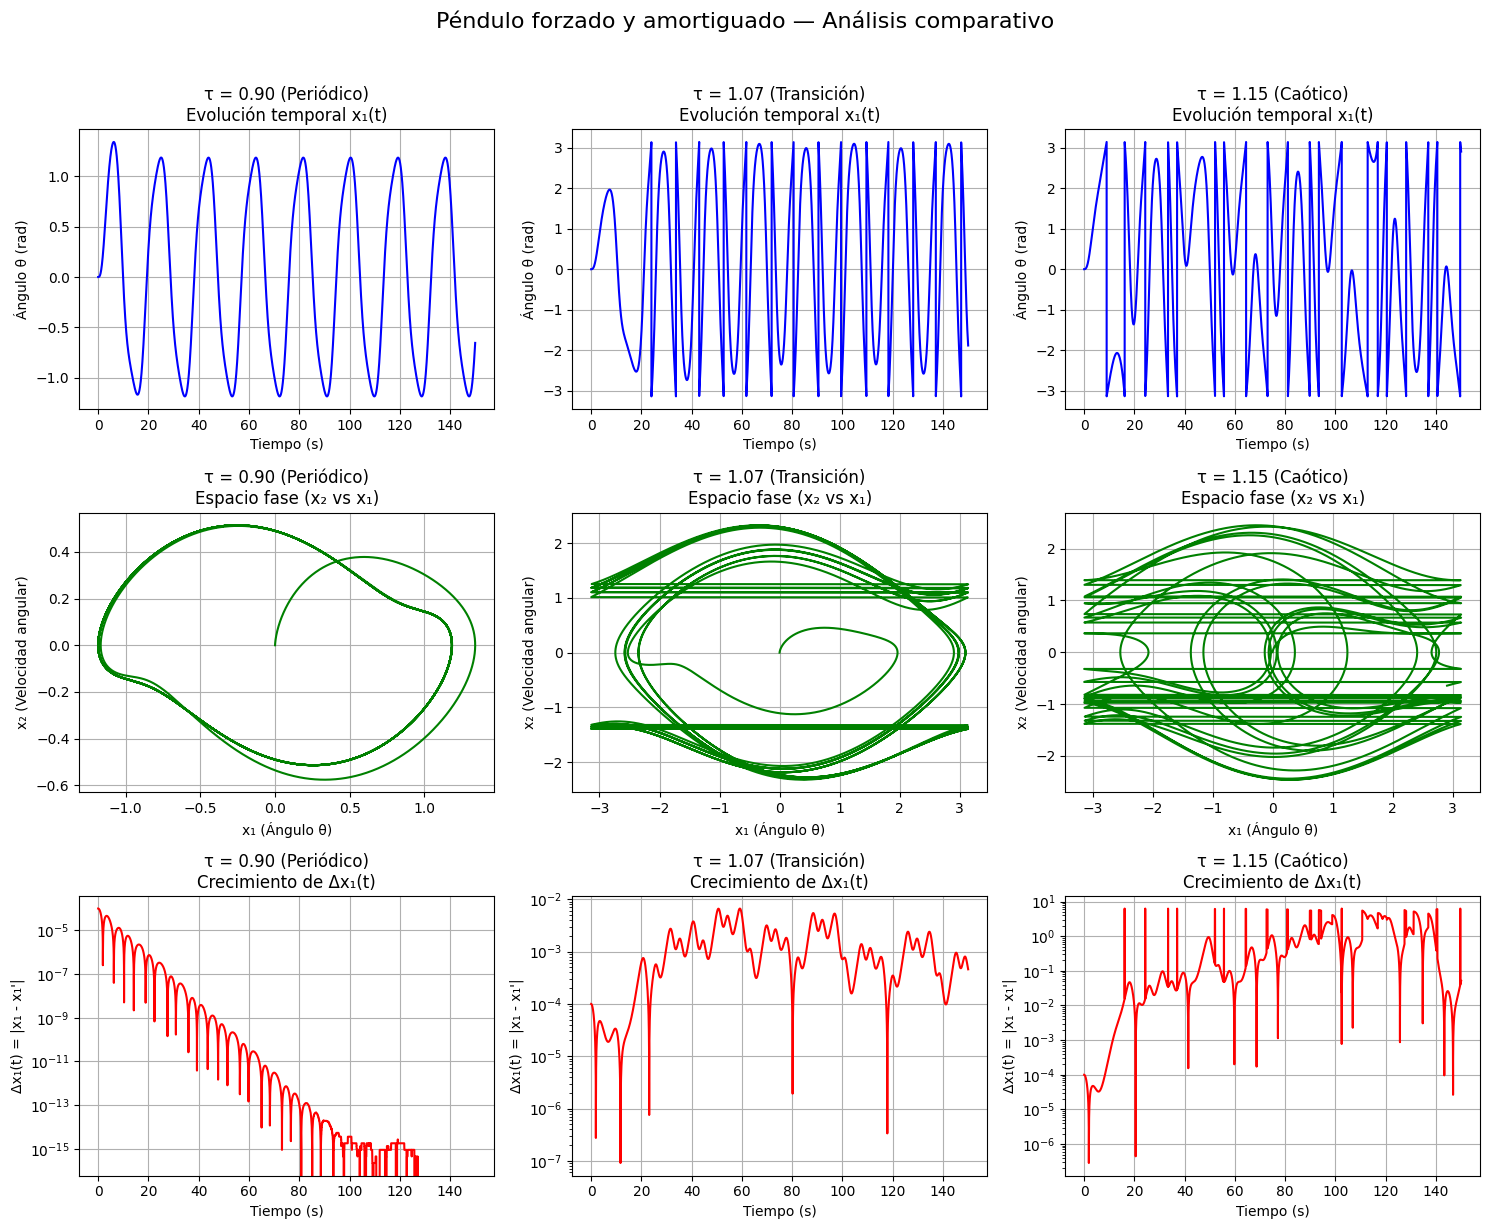

In [ ]:
# Proyecto 2.6.1: Péndulo forzado y amortiguado
# Método de Runge-Kutta de 4° orden (RK4)
# Nombre: Fierro Gutiérrez Daniela

import numpy as np
import matplotlib.pyplot as plt

# Definición de la ecuación del péndulo forzado y amortiguado
def pendulo_forzado(x1, x2, t, nu, tau, f):
    """
    x1 = θ (ángulo)
    x2 = dθ/dt (velocidad angular)
    Ecuación: d2θ/dt2 + ν dθ/dt + sin(θ) = τ sin(2π f t)
    """
    dx1 = x2
    dx2 = -nu * x2 - np.sin(x1) + tau * np.sin(2 * np.pi * f * t)
    return dx1, dx2


# Método de Runge-Kutta de 4º orden
def RK4_step(x1, x2, t, h, nu, tau, f):
    k1x1, k1x2 = pendulo_forzado(x1, x2, t, nu, tau, f)
    k2x1, k2x2 = pendulo_forzado(x1 + 0.5*h*k1x1, x2 + 0.5*h*k1x2, t + 0.5*h, nu, tau, f)
    k3x1, k3x2 = pendulo_forzado(x1 + 0.5*h*k2x1, x2 + 0.5*h*k2x2, t + 0.5*h, nu, tau, f)
    k4x1, k4x2 = pendulo_forzado(x1 + h*k3x1, x2 + h*k3x2, t + h, nu, tau, f)

    x1_new = x1 + (h/6)*(k1x1 + 2*k2x1 + 2*k3x1 + k4x1)
    x2_new = x2 + (h/6)*(k1x2 + 2*k2x2 + 2*k3x2 + k4x2)
    return x1_new, x2_new


# Simulación general
def simular_pendulo(nu, tau, f, x1_0, x2_0, h=0.01, tmax=200):
    n = int(tmax/h)
    t = np.linspace(0, tmax, n)
    x1 = np.zeros(n)
    x2 = np.zeros(n)

    x1[0], x2[0] = x1_0, x2_0

    for i in range(n-1):
        x1[i+1], x2[i+1] = RK4_step(x1[i], x2[i], t[i], h, nu, tau, f)
        x1[i+1] = (x1[i+1] + np.pi) % (2*np.pi) - np.pi  # mantener ángulo en [-π, π]

    return t, x1, x2


# Parámetros
nu = 0.5
f = 1/(6*np.pi)
parametros = [(0.90, "τ = 0.90 (Periódico)"),
              (1.07, "τ = 1.07 (Transición)"),
              (1.15, "τ = 1.15 (Caótico)")]

# Condiciones iniciales
x1_0_a, x1_0_b = 0.0, 0.0001
x2_0 = 0.0
h = 0.01
tmax = 150


# Simulaciones
resultados = []
for tau, titulo in parametros:
    t, x1_a, x2_a = simular_pendulo(nu, tau, f, x1_0_a, x2_0, h, tmax)
    _, x1_b, x2_b = simular_pendulo(nu, tau, f, x1_0_b, x2_0, h, tmax)
    delta_x1 = np.abs(x1_a - x1_b)
    resultados.append((tau, titulo, t, x1_a, x2_a, delta_x1))


# GRAFICACIÓN (por filas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ----- Fila 1: x₁(t) -----
for i, (tau, titulo, t, x1, x2, delta_x1) in enumerate(resultados):
    axes[0, i].plot(t, x1, color='blue')
    axes[0, i].set_title(f"{titulo}\nEvolución temporal x₁(t)")
    axes[0, i].set_xlabel("Tiempo (s)")
    axes[0, i].set_ylabel("Ángulo θ (rad)")
    axes[0, i].grid(True)

# ----- Fila 2: Espacio fase -----
for i, (tau, titulo, t, x1, x2, delta_x1) in enumerate(resultados):
    axes[1, i].plot(x1, x2, color='green')
    axes[1, i].set_title(f"{titulo}\nEspacio fase (x₂ vs x₁)")
    axes[1, i].set_xlabel("x₁ (Ángulo θ)")
    axes[1, i].set_ylabel("x₂ (Velocidad angular)")
    axes[1, i].grid(True)

# ----- Fila 3: Diferencia entre trayectorias -----
for i, (tau, titulo, t, x1, x2, delta_x1) in enumerate(resultados):
    axes[2, i].plot(t, delta_x1, color='red')
    axes[2, i].set_yscale('log')
    axes[2, i].set_title(f"{titulo}\nCrecimiento de Δx₁(t)")
    axes[2, i].set_xlabel("Tiempo (s)")
    axes[2, i].set_ylabel("Δx₁(t) = |x₁ - x₁'|")
    axes[2, i].grid(True)

plt.suptitle("Péndulo forzado y amortiguado — Análisis comparativo", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()